# Bus Route Analysis with Reusable Functions

This notebook demonstrates how to refactor the bus route analysis code into reusable functions that can be applied to different data tables.

## 1. Setup Environment and Imports

In [1]:
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Add parent directory to path if needed
sys.path.append(str(pathlib.Path.cwd()))

## 2. Define Reusable Processing Functions

All functions are self-contained and can be used on any table with compatible columns.

In [2]:
def load_and_clean_data(file_path):
    """Load CSV file and clean data by removing NaN values and duplicates."""
    df = pd.read_csv(file_path)
    
    # Remove rows with NaN in route_name
    df = df.dropna(subset=['route_name'])
    
    # Find and remove duplicate rows
    duplicates = df[df.duplicated()]
    print(f"Number of duplicate rows: {len(duplicates)}")
    df = df.drop_duplicates()
    
    return df


def sort_and_analyze_data(df):
    """Sort dataframe and analyze route blocks."""
    df_sorted = df.sort_values(['route_id', 'month', 'day_of_week', 'scheduled_departure_time', 'stop_sequence'])
    
    route_blocks = df_sorted.groupby(['route_id', 'month', 'day_of_week', 'scheduled_departure_time'])
    block_size = route_blocks.size().reset_index(name='n_stops')
    
    return df_sorted, route_blocks, block_size


def extract_route_sequences(route_blocks):
    """Extract route sequences from grouped data."""
    def get_route_sequence(group):
        return group.sort_values('stop_sequence')['stop_code'].tolist()
    
    route_sequences = route_blocks.apply(get_route_sequence).reset_index()
    route_sequences = route_sequences.rename(columns={0: 'route_sequence'})
    
    # Convert to string format
    route_sequences['route_sequence_str'] = route_sequences['route_sequence'].apply(
        lambda x: '-'.join(map(str, x))
    )
    
    # Count occurrences - properly handle value_counts() return
    route_counts = route_sequences['route_sequence_str'].value_counts().reset_index(name='count')
    route_counts = route_counts.rename(columns={'index': 'route_sequence_str'})
    
    # Add number of stops column
    route_counts['n_stops'] = route_counts['route_sequence_str'].apply(lambda x: len(x.split('-')))
    
    return route_sequences, route_counts


def get_most_common_route(route_counts):
    """Get the most common route sequence."""
    most_common_route_str = route_counts.iloc[0]['route_sequence_str']
    most_common_route = most_common_route_str.split('-')
    
    return most_common_route_str, most_common_route


def filter_and_classify_routes(route_counts, most_common_route_str):
    """Filter routes and classify by number of stops."""
    # Remove the most common route
    other_routes = route_counts[route_counts['route_sequence_str'] != most_common_route_str]
    
    # Sort by number of stops and count
    other_routes_sorted = other_routes.sort_values(by=['n_stops', 'count'])
    
    # Get distribution of stops
    stops_distribution = other_routes_sorted.groupby('n_stops').size().reset_index(name='n_routes')
    stops_distribution = stops_distribution.sort_values(by='n_stops')
    
    return other_routes_sorted, stops_distribution


def load_stops_mapping(stops_file):
    """Load stops information and create mapping from code to name."""
    stops_df = pd.read_csv(stops_file)
    stop_code_to_name = dict(zip(stops_df['stop_code'], stops_df['stop_name']))
    stop_code_to_name[2008] = 'צומת פת/הרב הרצוג'
    return stop_code_to_name


def get_stop_names(stop_codes, stop_code_to_name):
    """Convert stop codes string to list of stop names."""
    codes = stop_codes.split('-')
    names = [stop_code_to_name.get(int(code), f"Unknown({code})") for code in codes]
    return names

def compare_routes_to_reference(
        other_routes_sorted,
        most_common_route_str,
        stop_code_to_name):
    """
    Compare all routes against the most common route.

    Returns
    -------
    comparison_df : DataFrame
        One row per route variant.

    reference_stations : list
        Station names of the reference route.
    """

    # Reference route
    reference_codes = most_common_route_str.split('-')

    reference_stations = [
        stop_code_to_name.get(int(code), f"Unknown({code})")
        for code in reference_codes
    ]

    comparison_results = []

    for _, row in other_routes_sorted.iterrows():

        current_codes = row['route_sequence_str'].split('-')

        current_station_names = [
            stop_code_to_name.get(int(code), f"Unknown({code})")
            for code in current_codes
        ]

        # -----------------------------
        # Missing stations
        # -----------------------------
        missing_details = []

        for code in reference_codes:

            if code not in current_codes:

                ref_position = reference_codes.index(code)

                missing_details.append({
                    'stop_code': code,
                    'stop_name': stop_code_to_name.get(
                        int(code),
                        f"Unknown({code})"
                    ),
                    'reference_position': ref_position
                })

        # -----------------------------
        # Added stations
        # -----------------------------
        added_details = []

        for code in current_codes:

            if code not in reference_codes:

                current_position = current_codes.index(code)

                added_details.append({
                    'stop_code': code,
                    'stop_name': stop_code_to_name.get(
                        int(code),
                        f"Unknown({code})"
                    ),
                    'current_position': current_position
                })

        # -----------------------------
        # Save result
        # -----------------------------
        comparison_results.append({

            # route statistics
            'count': row['count'],
            'n_stops': row['n_stops'],

            # original route
            'route_sequence_str':
                row['route_sequence_str'],

            'route_sequence_names':
                current_station_names,

            # summary numbers
            'n_missing':
                len(missing_details),

            'n_added':
                len(added_details),

            # detailed info
            'missing_details':
                missing_details,

            'added_details':
                added_details
        })

    comparison_df = pd.DataFrame(comparison_results)

    comparison_df = comparison_df.sort_values(
        by='count',
        ascending=False
    )

    return comparison_df, reference_stations

def filter_by_stop_count(other_routes_sorted, min_stops=10, max_stops=50):
    """Filter routes by number of stops."""
    filtered_routes = other_routes_sorted[
        (other_routes_sorted['n_stops'] >= min_stops) & 
        (other_routes_sorted['n_stops'] <= max_stops)
    ]
    print(f"Number of routes after filtering ({min_stops}-{max_stops} stops): {len(filtered_routes)}")
    return filtered_routes


def create_heatmap_data(subset_routes, reference_stations, stop_code_to_name):
    """Create heatmap data showing which reference stations appear in each route."""
    heatmap_data = []
    labels_y = []
    
    for idx, row in subset_routes.iterrows():
        # Extract stops of current route
        current_route_stops = set(get_stop_names(row['route_sequence_str'], stop_code_to_name))
        
        # Build vector: 1 if stop from reference is in current route, 0 otherwise
        vector = [1 if stop in current_route_stops else 0 for stop in reference_stations]
        
        heatmap_data.append(vector)
        labels_y.append(f"Route {idx} (n = {row['count']})")
    
    heatmap_data = np.array(heatmap_data)
    return heatmap_data, labels_y


def plot_routes_heatmap(heatmap_data, reference_stations, labels_y, bin_label, line_number):
    """Plot heatmap showing route coverage."""
    station_labels_rtl = reference_stations
    station_labels_rtl = [label[::-1] if label != "" else "" for label in station_labels_rtl]
    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data, annot=False, cbar=False, cmap='YlGnBu',
                xticklabels=station_labels_rtl, yticklabels=labels_y,
                linecolor='black', linewidths=0.5)
    
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Heatmap for Line {line_number} routes with {bin_label} stops (0=absent, 1=present)")
    plt.ylabel("Route Index")
    plt.xlabel("Stations (in most common route order)")
    plt.tight_layout()
    plt.show()


def plot_rare_routes(other_routes_sorted):
    """Plot scatter plot of rare routes (stops vs occurrences)."""
    plt.figure(figsize=(10, 6))
    plt.scatter(other_routes_sorted['n_stops'], other_routes_sorted['count'], alpha=0.7)
    plt.xlabel('Number of stops in route')
    plt.ylabel('Number of occurrences')
    plt.title('Rare route sequences: number of stops vs occurrences')
    plt.grid(True)
    plt.show()

In [3]:
def remove_duplicate_stops(df_sorted):
    """
    Remove duplicate stop_sequence entries within each block.
    Each stop_sequence should appear exactly once per block.
    
    Args:
        df_sorted (pd.DataFrame): Sorted dataframe
        
    Returns:
        pd.DataFrame: Cleaned dataframe
    """
    print(f"Rows before removing duplicate stops: {len(df_sorted)}")
    
    df_clean = df_sorted.drop_duplicates(
        subset=['route_id', 'month', 'day_of_week', 'scheduled_departure_time', 'stop_sequence'],
        keep='first'
    )
    
    print(f"Rows after: {len(df_clean)}")
    
    check = df_clean.groupby(
        ['route_id', 'month', 'day_of_week', 'scheduled_departure_time', 'stop_sequence']
    ).size().reset_index(name='count')
    
    print("\nDistribution after cleaning (should be only 1):")
    print(check['count'].value_counts())
    
    return df_clean


In [4]:
def fix_stop_codes(df, stop_code_mapping):
    """
    Replace incorrect stop codes with correct ones.
    Should be called after remove_duplicate_stops, before extract_route_sequences.
    
    Args:
        df (pd.DataFrame): Sorted dataframe
        stop_code_mapping (dict): {wrong_code: correct_code}
        
    Returns:
        pd.DataFrame: Dataframe with corrected stop codes
    """
    df = df.copy()
    for wrong_code, correct_code in stop_code_mapping.items():
        mask = df['stop_code'] == wrong_code
        print(f"Replacing stop code {wrong_code} → {correct_code}: {mask.sum()} rows affected")
        df.loc[mask, 'stop_code'] = correct_code
    return df

In [5]:
def remove_duplicate_stops(df_sorted):
    """
    Remove duplicate stop_sequence entries within each block.
    Each stop_sequence should appear exactly once per block.
    
    Args:
        df_sorted (pd.DataFrame): Sorted dataframe
        
    Returns:
        pd.DataFrame: Cleaned dataframe
    """
    print(f"Rows before removing duplicate stops: {len(df_sorted)}")
    
    df_clean = df_sorted.drop_duplicates(
        subset=['route_id', 'month', 'day_of_week', 'scheduled_departure_time', 'stop_sequence'],
        keep='first'
    )
    
    print(f"Rows after: {len(df_clean)}")
    
    check = df_clean.groupby(
        ['route_id', 'month', 'day_of_week', 'scheduled_departure_time', 'stop_sequence']
    ).size().reset_index(name='count')
    
    print("\nDistribution after cleaning (should be only 1):")
    print(check['count'].value_counts())
    
    return df_clean


def phase_1_load_and_clean(ride_data_path):
    """
    Phase 1: Load, clean, sort and remove duplicates.
    Steps 1, 2, 2.5
    
    Args:
        ride_data_path (str): Path to ride data CSV
        
    Returns:
        tuple: (df_sorted, route_blocks)
    """
    print("Step 1: Loading and cleaning data...")
    df = load_and_clean_data(ride_data_path)
    print(f"Data shape after cleaning: {df.shape}")
    
    print("\nStep 2: Sorting and analyzing routes...")
    df_sorted, route_blocks, block_size = sort_and_analyze_data(df)
    
    print("\nStep 2.5: Removing duplicate stops within blocks...")
    df_sorted = remove_duplicate_stops(df_sorted)
    
    route_blocks = df_sorted.groupby(
        ['route_id', 'month', 'day_of_week', 'scheduled_departure_time']
    )
    
    return df_sorted, route_blocks


def phase_2_extract_sequences(route_blocks):
    """
    Phase 2: Extract route sequences, find most common route, 
    classify and plot rare routes.
    Steps 3-6
    
    Args:
        route_blocks: Grouped dataframe
        
    Returns:
        tuple: (route_counts, most_common_route_str, most_common_route, 
                other_routes_sorted, stops_distribution)
    """
    print("\nStep 3: Extracting route sequences...")
    route_sequences, route_counts = extract_route_sequences(route_blocks)
    print(f"Total unique route sequences: {route_counts.shape[0]}")
    
    print("\nStep 4: Finding most common route...")
    most_common_route_str, most_common_route = get_most_common_route(route_counts)
    print(f"Most common route has {route_counts.iloc[0]['n_stops']} stops")
    
    print("\nStep 5: Filtering and classifying routes...")
    other_routes_sorted, stops_distribution = filter_and_classify_routes(
        route_counts, most_common_route_str
    )
    
    print("\nStep 6: Plotting rare routes distribution...")
    plot_rare_routes(other_routes_sorted)
    
    return route_counts, most_common_route_str, most_common_route, \
           other_routes_sorted, stops_distribution


def phase_3_compare_routes(other_routes_sorted, most_common_route_str, 
                            stops_data_path, min_stops=10, max_stops=50):
    """
    Phase 3: Load stops mapping, filter routes and compare to reference.
    Steps 7-9.5
    
    Args:
        other_routes_sorted (pd.DataFrame): Sorted rare routes
        most_common_route_str (str): Most common route sequence
        stops_data_path (str): Path to stops CSV
        min_stops (int): Minimum number of stops
        max_stops (int): Maximum number of stops
        
    Returns:
        tuple: (filtered_routes, stop_code_to_name, 
                reference_stations, comparison_df)
    """
    print("\nStep 7: Filtering routes by stop count...")
    filtered_routes = filter_by_stop_count(
        other_routes_sorted, min_stops=min_stops, max_stops=max_stops
    )
    
    print("\nStep 8: Loading stops mapping...")
    stop_code_to_name = load_stops_mapping(stops_data_path)
    
    print("\nStep 9: Preparing reference stations...")
    reference_stations = get_stop_names(most_common_route_str, stop_code_to_name)
    print(f"Reference stations: {len(reference_stations)} stops")
    
    print("\nStep 9.5: Comparing routes to reference...")
    comparison_df, reference_stations = compare_routes_to_reference(
        other_routes_sorted, most_common_route_str, stop_code_to_name
    )
    display(comparison_df.head())
    
    return filtered_routes, stop_code_to_name, reference_stations, comparison_df


def phase_4_visualize(comparison_df, reference_stations, line_number):
    """
    Phase 4: Create heatmap and print added stops.
    Step 10
    
    Args:
        comparison_df (pd.DataFrame): Comparison results
        reference_stations (list): Reference station names
        line_number (str): Line number for plot title
    """
    print("\nStep 10: Creating heatmap...")
    heatmap_data, labels_y = create_heatmap_data_v3(comparison_df, reference_stations, route_counts, most_common_route_str)
    plot_routes_heatmap_v2(heatmap_data, reference_stations, labels_y, line_number)
    
    print("\nRoutes with added stops:")
    for _, row in comparison_df.iterrows():
        if row['n_added'] > 0:
            print(f"\nRoute: n={row['count']} | {row['n_stops']} stops")
            for detail in row['added_details']:
                print(f"  + {detail['stop_name']} (position {detail['current_position']})")

In [6]:
def run_full_analysis_2(ride_data_path, stops_data_path, 
                      min_stops=10, max_stops=50):
    """
    Run complete analysis pipeline in 4 phases.
    """
    line_number = ride_data_path.split("_")[-1].split(".")[0]
    print(f"{'='*60}")
    print(f"ANALYZING LINE: {line_number}")
    print(f"{'='*60}")
    
    df_sorted, route_blocks = phase_1_load_and_clean(ride_data_path)
    
    route_counts, most_common_route_str, most_common_route, \
        other_routes_sorted, stops_distribution = phase_2_extract_sequences(route_blocks)
    
    filtered_routes, stop_code_to_name, reference_stations, \
        comparison_df = phase_3_compare_routes(
            other_routes_sorted, most_common_route_str, 
            stops_data_path, min_stops, max_stops
        )
    
    phase_4_visualize(comparison_df, reference_stations, line_number)
    
    print("\nAnalysis complete!")
    
    return {
        'df_sorted': df_sorted,
        'route_counts': route_counts,
        'most_common_route_str': most_common_route_str,
        'comparison_df': comparison_df,
        'reference_stations': reference_stations,
        'stop_code_to_name': stop_code_to_name
    }

In [18]:
def create_heatmap_data_v2(comparison_df, reference_stations):
    """
    Create heatmap data with 3 values:
    0 = stop missing
    1 = stop present
    2 = has added stops (indicator column)
    """
    heatmap_data = []
    labels_y = []

    for _, row in comparison_df.iterrows():
        current_stops = set(row['route_sequence_names'])
        
        vector = [1 if stop in current_stops else 0 for stop in reference_stations]
        
        # indicator column: 2 if has added stops, 0 otherwise
        vector.append(2 if row['n_added'] > 0 else 0)
        
        heatmap_data.append(vector)
        labels_y.append(f"n={row['count']} | {row['n_stops']} stops")

    return np.array(heatmap_data), labels_y


def plot_routes_heatmap_v2(heatmap_data, reference_stations, labels_y, line_number):
    """
    Plot heatmap with 3 colors:
    white = missing, green = present, orange = has added stops
    """
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch

    cmap = ListedColormap(['#f7f7f7', '#1D9E75', '#E87C2A'])
    # , '#E87C2A'
    #columns = reference_stations + ['added stops']
    # Reverse RTL labels
    columns = [label[::-1] if label != "" else "" for label in reference_stations] + ['added stops']

    #station_labels_rtl = [label[::-1] if label != "" else "" for label in station_labels_rtl]

    plt.figure(figsize=(16, 7))
    sns.heatmap(heatmap_data, annot=False, cbar=False,
                cmap=cmap, vmin=0, vmax=2,
                xticklabels=columns, yticklabels=labels_y,
                linecolor='lightgrey', linewidths=0.3)

    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=9)
    plt.title(f"Route deviations from reference — Line {line_number}")
    plt.xlabel("Reference stations")
    plt.ylabel("Route variants (sorted by occurrences)")

    legend = [
        Patch(color='#1D9E75', label='Present'),
        Patch(color='#f7f7f7', label='Missing'),
        Patch(color='#E87C2A', label='Has added stops'),
    ]
    plt.legend(handles=legend, loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()


def create_heatmap_data_v3(comparison_df, reference_stations, route_counts, most_common_route_str):
    """
    Create heatmap data with 3 values:
    0 = stop missing
    1 = stop present
    2 = has added stops (indicator column)
    Reference route is added as first row.
    """
    heatmap_data = []
    labels_y = []

    # Add reference route as first row - all 1s
    ref_count = route_counts[route_counts['route_sequence_str'] == most_common_route_str].iloc[0]['count']
    reference_vector = [1] * len(reference_stations) + [0]
    heatmap_data.append(reference_vector)
    labels_y.append(f"REFERENCE n={ref_count} | {len(reference_stations)} stops")

    # Add all other routes
    for _, row in comparison_df.iterrows():
        current_stops = set(row['route_sequence_names'])
        vector = [1 if stop in current_stops else 0 for stop in reference_stations]
        vector.append(2 if row['n_added'] > 0 else 0)
        heatmap_data.append(vector)
        labels_y.append(f"n={row['count']} | {row['n_stops']} stops")

    return np.array(heatmap_data), labels_y


def phase_4_visualize(comparison_df, reference_stations, route_counts, 
                      most_common_route_str, line_number):
    """
    Phase 4: Create heatmap and print added stops.
    """
    print("\nStep 10: Creating heatmap...")
    heatmap_data, labels_y = create_heatmap_data_v3(
        comparison_df, reference_stations, route_counts, most_common_route_str
    )
    plot_routes_heatmap_v2(heatmap_data, reference_stations, labels_y, line_number)

    print("\nRoutes with added stops:")
    for _, row in comparison_df.iterrows():
        if row['n_added'] > 0:
            print(f"\nRoute: n={row['count']} | {row['n_stops']} stops")
            for detail in row['added_details']:
                print(f"  + {detail['stop_name']} (position {detail['current_position']})")

In [108]:
def create_heatmap_data_v4(comparison_df, reference_stations, route_counts, most_common_route_str, stop_code_to_name):
    
    # Find the longest route
    longest_route_row = comparison_df.loc[comparison_df['n_stops'].idxmax()]
    longest_route_stops = longest_route_row['route_sequence_names']  # זה כבר בסדר הנכון
    
    # X axis = סדר המסלול הארוך במלואו
    all_stations = longest_route_stops

    heatmap_data = []
    labels_y = []

    # Reference row
    ref_count = route_counts[route_counts['route_sequence_str'] == most_common_route_str].iloc[0]['count']
    ref_set = set(reference_stations)
    reference_vector = [1 if s in ref_set else 0 for s in all_stations]
    heatmap_data.append(reference_vector)
    labels_y.append(f"REFERENCE | n={ref_count} | {len(reference_stations)} stops")

    # All other routes
    for _, row in comparison_df.iterrows():
        current_stops = set(row['route_sequence_names'])
        vector = [1 if s in current_stops else 0 for s in all_stations]
        heatmap_data.append(vector)
        labels_y.append(f" n={row['count']} | {row['n_stops']} stops")

    return np.array(heatmap_data), labels_y, all_stations


def plot_routes_heatmap_v3(heatmap_data, all_stations, labels_y, line_number):
    """
    Plot heatmap: white = missing, green = present.
    X axis based on longest route.
    """
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch

    cmap = ListedColormap(['#f7f7f7', '#1D9E75'])
    columns = [label[::-1] if label else "" for label in all_stations]

    plt.figure(figsize=(16, 7))
    sns.heatmap(heatmap_data, annot=False, cbar=False,
                cmap=cmap, vmin=0, vmax=1,
                xticklabels=columns, yticklabels=labels_y,
                linecolor='lightgrey', linewidths=0.3)

    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=9)
    plt.title(f"Route deviations from reference — Line {line_number}")
    plt.xlabel("Stations (longest route order)")
    plt.ylabel("Route variants (sorted by occurrences)")

    legend = [
        Patch(color='#1D9E75', label='Present'),
        Patch(color='#f7f7f7', label='Missing'),
    ]
    plt.legend(handles=legend, loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()

In [126]:
def create_heatmap_data_v5(comparison_df, reference_stations, route_counts,
                            most_common_route_str, stop_code_to_name):
    """
    Create heatmap data with 3 values:
    0 = stop missing
    1 = stop present
    2 = has added stops (indicator column)
    Reference route is added as first row.
 
    label_y format: "variant 0 | n=412 | 18 stops"  ← עודכן
    """
    heatmap_data = []
    labels_y = []
 
    # שורת ייחוס — ראשונה
    ref_count = route_counts[
        route_counts['route_sequence_str'] == most_common_route_str
    ].iloc[0]['count']
 
    reference_vector = [1] * len(reference_stations) + [0]
    heatmap_data.append(reference_vector)
    labels_y.append(f"variant 0 | n={ref_count} | {len(reference_stations)} stops")
 
    # שאר הוריאנטים
    for _, row in comparison_df.iterrows():
        current_stops = set(row['route_sequence_names'])
        vector = [1 if stop in current_stops else 0 for stop in reference_stations]
        vector.append(2 if row['n_added'] > 0 else 0)
        heatmap_data.append(vector)
 
        variant_id = row['route_variant_id']  # ← חדש
        labels_y.append(
            f"variant {variant_id} | n={row['count']} | {row['n_stops']} stops"
        )
 
    return np.array(heatmap_data), labels_y, reference_stations
def compare_routes_to_reference_2(other_routes_sorted, most_common_route_str,
                                 stop_code_to_name):
    """
    Compare all routes against the most common route.
    מניח ש-other_routes_sorted כבר מכיל עמודת route_variant_id
    (אחרי route_counts['route_variant_id'] = range(len(route_counts))).
 
    Returns
    -------
    comparison_df : DataFrame — one row per route variant
    reference_stations : list
    """
    reference_codes = most_common_route_str.split('-')
    reference_stations = [
        stop_code_to_name.get(int(code), f"Unknown({code})")
        for code in reference_codes
    ]
 
    comparison_results = []
 
    for _, row in other_routes_sorted.iterrows():
        current_codes = row['route_sequence_str'].split('-')
        current_station_names = [
            stop_code_to_name.get(int(code), f"Unknown({code})")
            for code in current_codes
        ]
 
        # Missing stations
        missing_details = []
        for code in reference_codes:
            if code not in current_codes:
                missing_details.append({
                    'stop_code': code,
                    'stop_name': stop_code_to_name.get(int(code), f"Unknown({code})"),
                    'reference_position': reference_codes.index(code)
                })
 
        # Added stations
        added_details = []
        for code in current_codes:
            if code not in reference_codes:
                added_details.append({
                    'stop_code': code,
                    'stop_name': stop_code_to_name.get(int(code), f"Unknown({code})"),
                    'current_position': current_codes.index(code)
                })
 
        comparison_results.append({
            'route_variant_id': row['route_variant_id'],  # ← חדש
            'count':            row['count'],
            'n_stops':          row['n_stops'],
            'route_sequence_str':   row['route_sequence_str'],
            'route_sequence_names': current_station_names,
            'n_missing':    len(missing_details),
            'n_added':      len(added_details),
            'missing_details': missing_details,
            'added_details':   added_details,
        })
 
    comparison_df = pd.DataFrame(comparison_results).sort_values(
        by='count', ascending=False
    )
 
    return comparison_df, reference_stations
 


 
 

In [122]:
def build_sequence_to_variant_map(route_counts):
    """
    בונה מילון: route_sequence_str → variant_id (אינדקס פוזיציוני).
    variant_id=0 הוא המסלול הנפוץ ביותר.
 
    Parameters
    ----------
    route_counts : pd.DataFrame
        פלט של extract_route_sequences, ממוין לפי count יורד.
 
    Returns
    -------
    dict : {route_sequence_str -> int}
    """
    sequence_to_variant_map = {
        row.route_sequence_str: idx
        for idx, row in enumerate(route_counts.itertuples(index=False))
    }
    print(f"Variant map built: {len(sequence_to_variant_map)} unique sequences.")
    return sequence_to_variant_map

def assign_variant_ids(df_sorted, sequence_to_variant_map):
    """
    מוסיף עמודה route_variant_id לכל שורה ב-df_sorted.
 
    לכל בלוק נסיעה (route_id + month + day_of_week + departure_time)
    בונה את route_sequence_str מ-stop_code לפי stop_sequence,
    ומשייך את ה-variant_id דרך המילון.
    אם רצף לא נמצא → NaN.
 
    Parameters
    ----------
    df_sorted : pd.DataFrame
        לאחר remove_duplicate_stops ו-fix_stop_codes.
    sequence_to_variant_map : dict
        פלט של build_sequence_to_variant_map.
 
    Returns
    -------
    pd.DataFrame : df_sorted + עמודה route_variant_id (Int64)
    """
    block_keys = ['route_id', 'month', 'day_of_week', 'scheduled_departure_time']
 
    # בונה string לכל בלוק (df_sorted כבר ממוין לפי stop_sequence)
    block_sequences = (
        df_sorted
        .groupby(block_keys, sort=False)['stop_code']
        .apply(lambda codes: '-'.join(codes.astype(str).tolist()))
        .reset_index()
        .rename(columns={'stop_code': 'route_sequence_str'})
    )
 
    # ממפה ל-variant_id
    block_sequences['route_variant_id'] = (
        block_sequences['route_sequence_str']
        .map(sequence_to_variant_map)
    )
 
    # אזהרה אם יש NaN
    n_missing = block_sequences['route_variant_id'].isna().sum()
    if n_missing > 0:
        print(f"WARNING: {n_missing} trips could not be matched → NaN assigned.")
        print(block_sequences[block_sequences['route_variant_id'].isna()]
              ['route_sequence_str'].head())
    else:
        print(f"All {len(block_sequences)} trips matched successfully.")
 
    # מחבר חזרה ל-df_sorted
    df_cleaned = df_sorted.merge(
        block_sequences[block_keys + ['route_variant_id']],
        on=block_keys,
        how='left'
    )
 
    # Int64 תומך ב-NaN (בניגוד ל-int64)
    df_cleaned['route_variant_id'] = df_cleaned['route_variant_id'].astype('Int64')
 
    print(f"Done. Unique variants in df_cleaned: "
          f"{df_cleaned['route_variant_id'].nunique()}")
    return df_cleaned

def save_cleaned_data(df_cleaned, ride_data_path):
    """
    שומרת df_cleaned כ-df_cleaned_XX.csv באותה תיקייה של ride_data_path.
 
    Parameters
    ----------
    df_cleaned : pd.DataFrame
    ride_data_path : str
 
    Returns
    -------
    str : נתיב הקובץ שנשמר
    """
    import pathlib
    source_path = pathlib.Path(ride_data_path)
    line_number  = source_path.stem.split('_')[-1]
    output_path  = source_path.parent / f"df_cleaned_{line_number}.csv"
 
    df_cleaned.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"Saved → {output_path}  ({len(df_cleaned):,} rows)")
    return str(output_path)
 
 
 

In [194]:
def save_filtered_data(df_filtered, ride_data_path):
    import pathlib
    source_path = pathlib.Path(ride_data_path)
    line_number  = source_path.stem.split('_')[-1]
    output_path  = source_path.parent / f"clean_filtered_data_{line_number}.csv"
    df_filtered.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"Saved → {output_path}  ({len(df_filtered):,} rows)")
    return str(output_path)

In [142]:
# ══════════════════════════════════════════════════════════════
# פונקציה מעודכנת — רק labels_y השתנה, שאר הפונקציה זהה לחלוטין
# ══════════════════════════════════════════════════════════════
 
def create_heatmap_data_v5(comparison_df, reference_stations, route_counts,
                            most_common_route_str, stop_code_to_name):
 
    # Find the longest route
    longest_route_row = comparison_df.loc[comparison_df['n_stops'].idxmax()]
    longest_route_stops = longest_route_row['route_sequence_names']
 
    # X axis = סדר המסלול הארוך במלואו
    all_stations = longest_route_stops
 
    heatmap_data = []
    labels_y = []
 
    # Reference row
    ref_count = route_counts[route_counts['route_sequence_str'] == most_common_route_str].iloc[0]['count']
    ref_set = set(reference_stations)
    reference_vector = [1 if s in ref_set else 0 for s in all_stations]
    heatmap_data.append(reference_vector)
    labels_y.append(f"variant 0 | REFERENCE | n={ref_count} | {len(reference_stations)} stops")  # ← חדש: נוסף variant 0
 
    # All other routes
    for _, row in comparison_df.iterrows():
        current_stops = set(row['route_sequence_names'])
        vector = [1 if s in current_stops else 0 for s in all_stations]
        heatmap_data.append(vector)
        labels_y.append(f"variant {row['route_variant_id']} | n={row['count']} | {row['n_stops']} stops")  # ← חדש: נוסף variant id
 
    return np.array(heatmap_data), labels_y, all_stations
 
 
# ══════════════════════════════════════════════════════════════
# פונקציה מעודכנת — רק נוסף route_variant_id לתוצאה
# ══════════════════════════════════════════════════════════════
 
def compare_routes_to_reference2(other_routes_sorted, most_common_route_str, stop_code_to_name):
    """
    Compare all routes against the most common route.
    מניח ש-other_routes_sorted מכיל עמודת route_variant_id.
    """
    reference_codes = most_common_route_str.split('-')
    reference_stations = [
        stop_code_to_name.get(int(code), f"Unknown({code})")
        for code in reference_codes
    ]
 
    comparison_results = []
 
    for _, row in other_routes_sorted.iterrows():
        current_codes = row['route_sequence_str'].split('-')
        current_station_names = [
            stop_code_to_name.get(int(code), f"Unknown({code})")
            for code in current_codes
        ]
 
        # Missing stations
        missing_details = []
        for code in reference_codes:
            if code not in current_codes:
                missing_details.append({
                    'stop_code': code,
                    'stop_name': stop_code_to_name.get(int(code), f"Unknown({code})"),
                    'reference_position': reference_codes.index(code)
                })
 
        # Added stations
        added_details = []
        for code in current_codes:
            if code not in reference_codes:
                added_details.append({
                    'stop_code': code,
                    'stop_name': stop_code_to_name.get(int(code), f"Unknown({code})"),
                    'current_position': current_codes.index(code)
                })
 
        comparison_results.append({
            'route_variant_id':     row['route_variant_id'],   # ← חדש
            'count':                row['count'],
            'n_stops':              row['n_stops'],
            'route_sequence_str':   row['route_sequence_str'],
            'route_sequence_names': current_station_names,
            'n_missing':            len(missing_details),
            'n_added':              len(added_details),
            'missing_details':      missing_details,
            'added_details':        added_details,
        })
 
    comparison_df = pd.DataFrame(comparison_results).sort_values(
        by='count', ascending=False
    )
 
    return comparison_df, reference_stations
 





In [189]:
def filter_routes_for_heatmap(other_routes_sorted, route_counts, line_number,
                               min_stops=10, max_stops=60, min_count=5):
    """
    מסנן מסלולים להצגה במפת החום.

    כלול מסלול אם:
        (min_stops ≤ n_stops ≤ max_stops)
        AND
        (count ≥ min_count  OR  דילג על לפחות תחנה אחת מ-CRITICAL_STOPS)

    Parameters
    ----------
    other_routes_sorted : pd.DataFrame
        פלט של filter_and_classify_routes.
    route_counts : pd.DataFrame
        מכיל route_variant_id — לצורך merge פנימי.
    line_number : str
    min_stops : int
    max_stops : int
    min_count : int

    Returns
    -------
    pd.DataFrame : המסלולים שעוברים את הפילטר, כולל route_variant_id
    """
    critical_stops = CRITICAL_STOPS.get(line_number, [])
    critical_stops_str = set(str(s) for s in critical_stops)

    # פילטר תחנות — תמיד חל
    mask_stops = (
        (other_routes_sorted['n_stops'] >= min_stops) &
        (other_routes_sorted['n_stops'] <= max_stops)
    )

    # פילטר count
    mask_count = other_routes_sorted['count'] >= min_count

    # פילטר critical
    def skips_critical(route_sequence_str):
        if not critical_stops_str:
            return False
        route_codes = set(route_sequence_str.split('-'))
        return bool(critical_stops_str - route_codes)

    mask_critical = other_routes_sorted['route_sequence_str'].apply(skips_critical)

    # לוגיקה סופית
    mask_final = mask_stops & (mask_count | mask_critical)
    filtered = other_routes_sorted[mask_final].copy()
    # debug זמני
    print("filtered columns before drop:", filtered.columns.tolist())
    if 'route_variant_id' in filtered.columns:
        filtered = filtered.drop(columns=['route_variant_id'])
    print("filtered columns after drop:", filtered.columns.tolist())

    filtered = filtered.merge(
    route_counts[['route_sequence_str', 'route_variant_id']],
    on='route_sequence_str',
    how='left'
)
    # merge של route_variant_id — נעשה כאן בפנים
    if 'route_variant_id' in filtered.columns:
        filtered = filtered.drop(columns=['route_variant_id'])

    # merge של route_variant_id — נעשה כאן בפנים
    filtered = filtered.merge(
        route_counts[['route_sequence_str', 'route_variant_id']],
        on='route_sequence_str',
        how='left'
    )

    # דיווח
    n_by_count    = (mask_stops & mask_count).sum()
    n_by_critical = (mask_stops & mask_critical & ~mask_count).sum()
    print(f"Routes passing stop-count filter ({min_stops}-{max_stops}): {mask_stops.sum()}")
    print(f"  → by frequency (≥{min_count} occurrences): {n_by_count}")
    print(f"  → by critical stops only (added):          {n_by_critical}")
    print(f"  → total for heatmap:                       {len(filtered)}")
    print(filtered.columns.tolist())

    if n_by_critical > 0 and critical_stops_str:
        print(f"\nCritical routes added (skipped important stops):")
        critical_only = filtered[mask_stops[mask_final].values & 
                                 mask_critical[mask_final].values & 
                                 ~mask_count[mask_final].values]
        for _, row in critical_only.iterrows():
            route_codes = set(row['route_sequence_str'].split('-'))
            skipped = [s for s in critical_stops if str(s) not in route_codes]
            print(f"  variant {row['route_variant_id']} | "
                  f"n={row['count']} | {row['n_stops']} stops | "
                  f"skipped: {skipped}")

    return filtered

In [196]:
def save_comparison_data(comparison_df, route_counts, most_common_route_str, 
                          reference_stations, ride_data_path):
    """
    שומרת טבלת סיכום וריאנטים — שורה אחת לכל וריאנט שעבר סינון + שורת ref.
    """
    import pathlib

    # שורת ref
    ref_count = route_counts[
        route_counts['route_sequence_str'] == most_common_route_str
    ].iloc[0]['count']

    ref_row = pd.DataFrame([{
        'route_variant_id': 0,
        'count':            ref_count,
        'n_stops':          len(reference_stations),
        'route_sequence_str': most_common_route_str,
        'is_reference':     True,
        'n_missing':        0,
        'n_added':          0,
        'missing_details':  [],
        'added_details':    [],
    }])

    # comparison_df + עמודת is_reference
    comp = comparison_df.copy()
    comp['is_reference'] = False

    # איחוד
    summary_df = pd.concat([ref_row, comp], ignore_index=True)

    # שמירה
    source_path = pathlib.Path(ride_data_path)
    line_number  = source_path.stem.split('_')[-1]
    output_path  = source_path.parent / f"variant_summary_{line_number}.csv"

    # עמודות list לא נשמרות יפה ב-csv — ממירים ל-string
    for col in ['missing_details', 'added_details']:
        summary_df[col] = summary_df[col].astype(str)

    summary_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"Saved → {output_path}  ({len(summary_df)} variants)")
    return summary_df

In [199]:
def clean_duplicate_stops(df_sorted, stop_code_fixes=None):
    """
    מסיר כפילויות ומתקן קודי עצירה שגויים.

    Parameters
    ----------
    df_sorted : pd.DataFrame
    stop_code_fixes : dict, optional
        {wrong_code: correct_code} — ברירת מחדל: {2008: 1525}

    Returns
    -------
    pd.DataFrame : df נקי
    """
    if stop_code_fixes is None:
        stop_code_fixes = {2008: 1525}

    print(f"Rows before: {len(df_sorted)}")

    df_clean = df_sorted.drop_duplicates(
        subset=['route_id', 'month', 'day_of_week', 'scheduled_departure_time', 'stop_sequence'],
        keep='first'
    )

    print(f"Rows after: {len(df_clean)}")

    df_clean = fix_stop_codes(df_clean, stop_code_fixes)

    # Verify
    check = df_clean.groupby(
        ['route_id', 'month', 'day_of_week', 'scheduled_departure_time', 'stop_sequence']
    ).size().reset_index(name='count')

    print("\nDistribution after cleaning (should be only 1):")
    print(check['count'].value_counts())

    return df_clean

## Section 3: the analysis pipeline that calls those functions

In [149]:
# Configure paths - change these to analyze different tables
ride_data_path = r"C:\Users\User\Documents\שנה ג\data_science\data-science\govData\renamed_ride_data_17.csv"
stops_data_path = r"C:\Users\User\Documents\שנה ג\data_science\data-science\govData\jerusalem_stops.csv"

CRITICAL_STOPS = {
    '17': [1054, 1575, 1484, 1079, 1080, 1544, 1546],
    '19': [1054, 1575, 1484, 1079, 1080, 1544, 1546],
    '22': [1054, 1575, 1484, 1079, 3857],
}

line_number = ride_data_path.split("_")[-1].split(".")[0]
print(f"Line Number: {line_number}")

print("=" * 60)
print("ANALYZING TABLE:", ride_data_path.split("\\")[-1])
print("=" * 60)

# Step 1: Load and clean data
print("\n1. Loading and cleaning data...")
df = load_and_clean_data(ride_data_path)
print(f"Data shape after cleaning: {df.shape}")

# Step 2: Sort and analyze
print("\n2. Sorting and analyzing routes...")
df_sorted, route_blocks, block_size = sort_and_analyze_data(df)



Line Number: 17
ANALYZING TABLE: renamed_ride_data_17.csv

1. Loading and cleaning data...
Number of duplicate rows: 6084
Data shape after cleaning: (24535, 13)

2. Sorting and analyzing routes...


In [200]:
# Step 2.5
print("\n2.5 Removing duplicate stops within blocks...")
df_sorted = clean_duplicate_stops(df_sorted)


2.5 Removing duplicate stops within blocks...
Rows before: 24535
Rows after: 21394
Replacing stop code 2008 → 1525: 326 rows affected

Distribution after cleaning (should be only 1):
count
1    21394
Name: count, dtype: int64


In [141]:
# Recreate route_blocks from clean df_sorted
route_blocks = df_sorted.groupby(['route_id', 'month', 'day_of_week', 'scheduled_departure_time'])


# Step 3: Extract sequences

print("\n3. Extracting route sequences...")
route_sequences, route_counts = extract_route_sequences(route_blocks)
print(f"Total unique route sequences: {route_counts.shape[0]}")

# After extract_route_sequences, add debugging:
print("\nDEBUGGING extract_route_sequences output:")
print(f"Type of route_counts: {type(route_counts)}")
print(f"Columns: {route_counts.columns.tolist() if hasattr(route_counts, 'columns') else 'N/A'}")
print(f"First row:\n{route_counts.head(1)}")
print(f"Data:\n{route_counts.dtypes}")

# ← חדש: שורה אחת מיד אחרי extract_route_sequences
route_counts['route_variant_id'] = range(len(route_counts))



3. Extracting route sequences...
Total unique route sequences: 77

DEBUGGING extract_route_sequences output:
Type of route_counts: <class 'pandas.DataFrame'>
Columns: ['route_sequence_str', 'count', 'n_stops']
First row:
                                  route_sequence_str  count  n_stops
0  6004-6081-9995-6124-3027-3004-9975-3561-9882-3...    287       47
Data:
route_sequence_str      str
count                 int64
n_stops               int64
dtype: object


In [123]:
sequence_to_variant_map = build_sequence_to_variant_map(route_counts)
df_cleaned = assign_variant_ids(df_sorted, sequence_to_variant_map)
saved_path = save_cleaned_data(df_cleaned, ride_data_path)

Variant map built: 77 unique sequences.
All 503 trips matched successfully.
Done. Unique variants in df_cleaned: 77
Saved → C:\Users\User\Documents\שנה ג\data_science\data-science\govData\df_cleaned_17.csv  (21,394 rows)



4. Finding most common route...
Most common route has 47 stops

5. Filtering and classifying routes...

6. Plotting rare routes distribution...


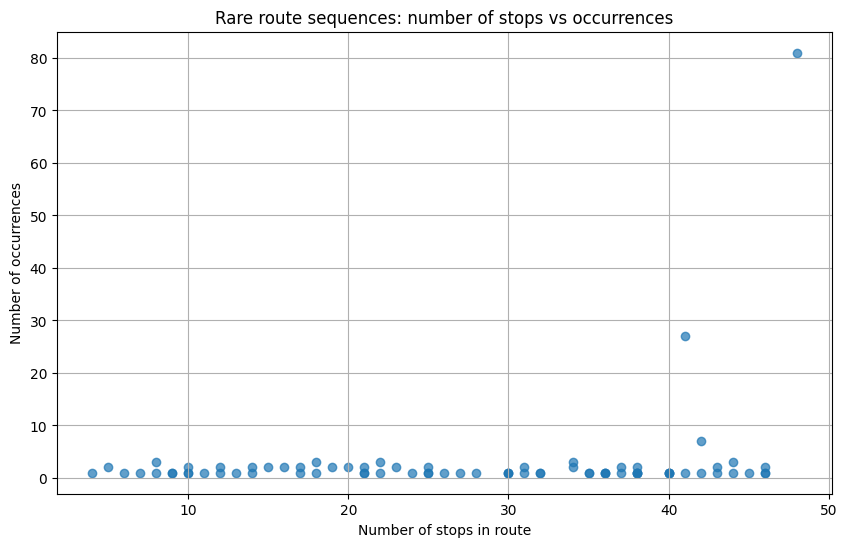

In [180]:
# Step 4: Get most common route
print("\n4. Finding most common route...")
most_common_route_str, most_common_route = get_most_common_route(route_counts)
print(f"Most common route has {route_counts.iloc[0]['n_stops']} stops")

# Step 5: Filter and classify
print("\n5. Filtering and classifying routes...")
other_routes_sorted, stops_distribution = filter_and_classify_routes(route_counts, most_common_route_str)


# Step 6: Plot rare routes distribution
print("\n6. Plotting rare routes distribution...")
plot_rare_routes(other_routes_sorted) 




In [190]:
 #Step 7 + 7.5: במקום שני הבלוקים הקיימים — בלוק אחד חדש
print("\n7. Filtering routes for heatmap...")
filtered_routes = filter_routes_for_heatmap(
    other_routes_sorted,
    route_counts = route_counts,
    line_number=line_number,
    min_stops=20,
    max_stops=60,
    min_count=5
)


7. Filtering routes for heatmap...
filtered columns before drop: ['route_sequence_str', 'count', 'n_stops', 'route_variant_id']
filtered columns after drop: ['route_sequence_str', 'count', 'n_stops']
Routes passing stop-count filter (20-60): 52
  → by frequency (≥5 occurrences): 3
  → by critical stops only (added):          17
  → total for heatmap:                       20
['route_sequence_str', 'count', 'n_stops', 'route_variant_id']

Critical routes added (skipped important stops):
  variant 10 | n=2 | 20 stops | skipped: [1054, 1575, 1484, 1079, 1080, 1544]
  variant 47 | n=1 | 21 stops | skipped: [1054, 1575, 1484, 1079, 1080]
  variant 69 | n=1 | 21 stops | skipped: [1575, 1484, 1079, 1080, 1544, 1546]
  variant 25 | n=2 | 21 stops | skipped: [1054, 1575, 1484, 1079, 1080, 1544, 1546]
  variant 31 | n=1 | 22 stops | skipped: [1054, 1575, 1484, 1079]
  variant 4 | n=3 | 22 stops | skipped: [1054, 1575, 1484, 1079, 1080, 1544, 1546]
  variant 23 | n=2 | 23 stops | skipped: [1054,

In [197]:

# Step 8: Load stops mapping
print("\n8. Loading stops mapping...")
stop_code_to_name = load_stops_mapping(stops_data_path)


# Step 9: Prepare reference stations
print("\n9. Preparing reference stations from most common route...")
reference_stations = get_stop_names(most_common_route_str, stop_code_to_name)
print(f"Reference stations: {len(reference_stations)} stops")

#print(filtered_routes.columns.tolist())

# step 9.5 - add debugging for reference stations
print("\nDEBUGGING reference stations:")

print(filtered_routes.columns.tolist())
comparison_df, reference_stations = compare_routes_to_reference2(
    filtered_routes, most_common_route_str, stop_code_to_name
)
display(comparison_df.head())

summary_df = save_comparison_data(
    comparison_df, route_counts, most_common_route_str, reference_stations, ride_data_path)




8. Loading stops mapping...

9. Preparing reference stations from most common route...
Reference stations: 47 stops

DEBUGGING reference stations:
['route_sequence_str', 'count', 'n_stops', 'route_variant_id']


,route_variant_id,count,n_stops,route_sequence_str,route_sequence_names,n_missing,n_added,missing_details,added_details
19,1,81,48,6004-6081-9995-6124-3027-3004-9975-3561-9882-3...,"[אריה דולצ'ין/יעקב צור, דולצ'ין/נחמיה, דולצ'ין...",0,1,[],"[{'stop_code': '1698', 'stop_name': 'בית הנוער..."
16,2,27,41,6004-6081-9995-6124-3027-3004-9975-3561-9882-3...,"[אריה דולצ'ין/יעקב צור, דולצ'ין/נחמיה, דולצ'ין...",6,0,"[{'stop_code': '1575', 'stop_name': 'עזה/הרב ב...",[]
17,3,7,42,6004-6081-9995-6124-3027-3004-9975-3561-9882-3...,"[אריה דולצ'ין/יעקב צור, דולצ'ין/נחמיה, דולצ'ין...",6,1,"[{'stop_code': '1575', 'stop_name': 'עזה/הרב ב...","[{'stop_code': '1698', 'stop_name': 'בית הנוער..."
5,4,3,22,6004-6081-9995-6124-3027-3004-9975-3561-9882-3...,"[אריה דולצ'ין/יעקב צור, דולצ'ין/נחמיה, דולצ'ין...",26,1,"[{'stop_code': '1054', 'stop_name': 'הרצוג/טשר...","[{'stop_code': '1698', 'stop_name': 'בית הנוער..."
10,22,2,25,6004-6081-9995-6124-3027-3004-9975-3561-9882-3...,"[אריה דולצ'ין/יעקב צור, דולצ'ין/נחמיה, דולצ'ין...",23,1,"[{'stop_code': '1079', 'stop_name': 'עזה/בלפור...","[{'stop_code': '1698', 'stop_name': 'בית הנוער..."


Saved → C:\Users\User\Documents\שנה ג\data_science\data-science\govData\variant_summary_17.csv  (21 variants)



10. Creating heatmap data...


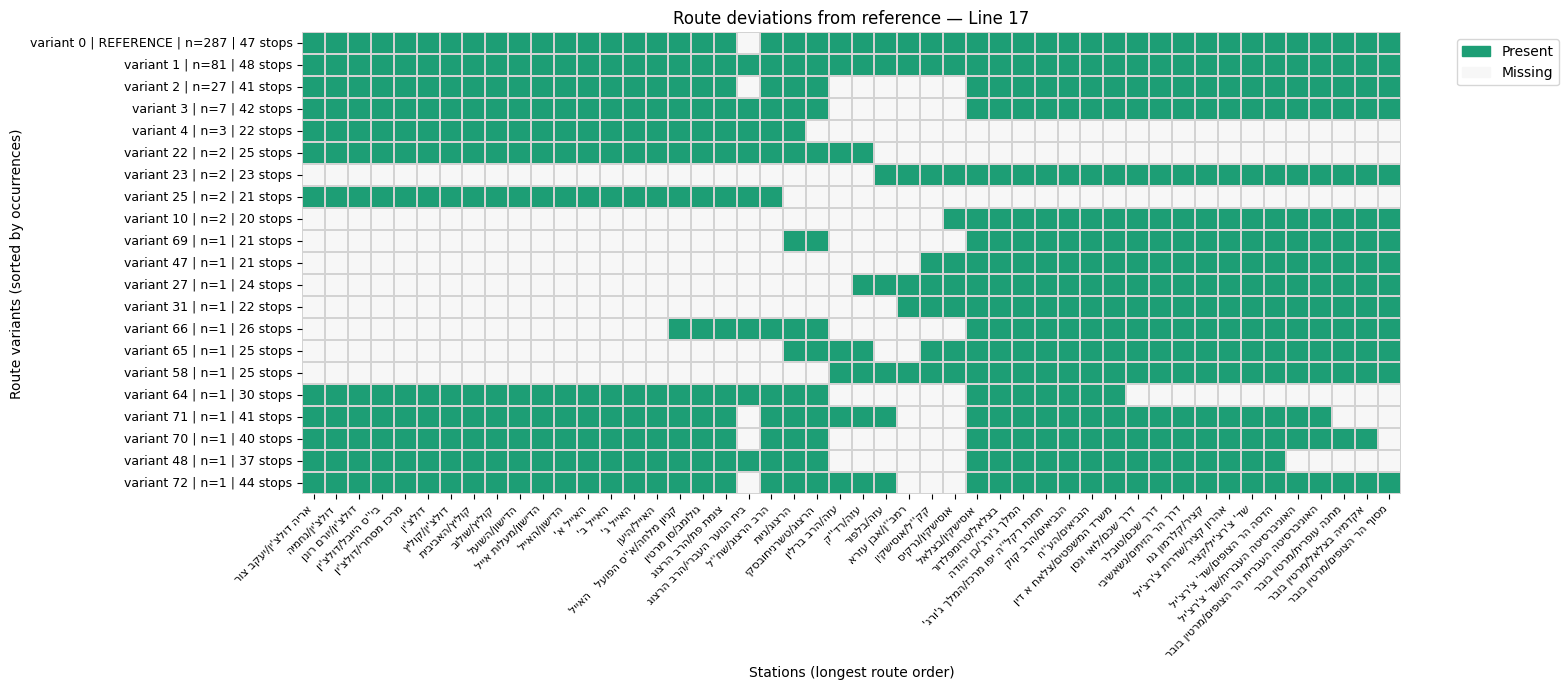

In [198]:
# Step 10: Create heatmap data
print("\n10. Creating heatmap data...")
heatmap_data, labels_y, all_stations = create_heatmap_data_v5(
    comparison_df, reference_stations, route_counts, most_common_route_str, stop_code_to_name
)
plot_routes_heatmap_v3(heatmap_data, all_stations, labels_y, line_number)


In [195]:
# variant_ids שעברו סינון + ה-ref (0)
valid_variant_ids = set(filtered_routes['route_variant_id'].tolist() + [0])

# סינון df_cleaned
df_filtered = df_cleaned[df_cleaned['route_variant_id'].isin(valid_variant_ids)].copy()

print(f"df_cleaned rows: {len(df_cleaned):,}")
print(f"df_filtered rows: {len(df_filtered):,}")
print(f"Unique variants in df_filtered: {df_filtered['route_variant_id'].nunique()}")

# שמירת df_filtered
filtered_path = save_filtered_data(df_filtered, ride_data_path)

df_cleaned rows: 21,394
df_filtered rows: 19,378
Unique variants in df_filtered: 21
Saved → C:\Users\User\Documents\שנה ג\data_science\data-science\govData\clean_filtered_data_17.csv  (19,378 rows)
